# Basic preprocessing and EDA 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

D = Path("../data/interim/sample_10pct")   # switch to sample_10pct for final numbers

ratings = pd.read_parquet(D / "ratings.parquet")
movies  = pd.read_parquet(D / "movies.parquet")
tags    = pd.read_parquet(D / "tags.parquet")

print("ratings", ratings.shape, "| movies", movies.shape, "| tags", tags.shape)
ratings.head()

ratings (3237353, 4) | movies (87585, 3) | tags (94469, 4)


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [12]:
ratings.info()
print("nulls:\n", ratings.isna().sum())
print("duplicate (user, movie) pairs:", ratings.duplicated(["userId", "movieId"]).sum())
print("users:", ratings.userId.nunique(), "| movies rated:", ratings.movieId.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 3237353 entries, 0 to 3237352
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int32  
 1   movieId    int32  
 2   rating     float32
 3   timestamp  int64  
dtypes: float32(1), int32(2), int64(1)
memory usage: 61.7 MB
nulls:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
duplicate (user, movie) pairs: 0
users: 20094 | movies rated: 42912


# Checking the rating distribution 

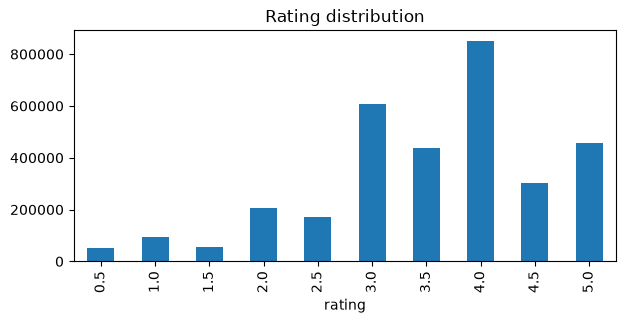

mean: 3.537 | median: 3.5


In [13]:
counts = ratings["rating"].value_counts().sort_index()
counts.plot.bar(figsize=(7, 3), title="Rating distribution")
plt.show()
print("mean:", ratings.rating.mean().round(3), "| median:", ratings.rating.median())

# The long tail: activity per user and per movie

The goal is to measure how unevenly ratings are spread across users and movies.

**Why:** this is the defining property of recommender data. A few blockbusters get thousands of ratings while most movies get very few, and those rarely-rated movies can't be learned from ratings alone. This drives three decisions: minimum-rating thresholds, how to handle **cold start** (the reason the content-based half exists), and how to guard against **popularity bias**.

**Look for:** a heavy tail on a log scale, the 99th percentile versus the median, and `min = 20` ratings per user (a MovieLens guarantee).

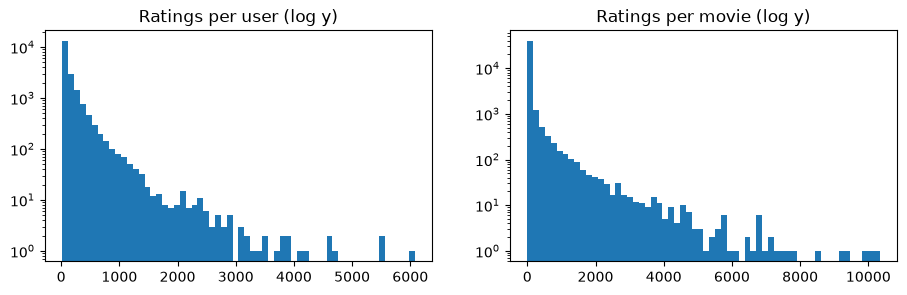

count    20094.0
mean       161.1
std        277.0
min         20.0
50%         74.0
90%        366.0
99%       1292.1
max       6074.0
dtype: float64
count    42912.0
mean        75.4
std        362.3
min          1.0
50%          3.0
90%        107.0
99%       1549.9
max      10330.0
dtype: float64


In [14]:
per_user  = ratings.groupby("userId").size()
per_movie = ratings.groupby("movieId").size()

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(per_user, bins=60, log=True);  ax[0].set_title("Ratings per user (log y)")
ax[1].hist(per_movie, bins=60, log=True); ax[1].set_title("Ratings per movie (log y)")
plt.show()

print(per_user.describe(percentiles=[.5, .9, .99]).round(1))
print(per_movie.describe(percentiles=[.5, .9, .99]).round(1))

# Sparsity and popularity concentration

Quantify how empty the user-item matrix is and how much of the data the most popular movies account for.

**Why:** extreme sparsity (>99% empty) is why we favour models that learn compact latent factors (matrix factorization) over methods that need overlapping ratings between users. The concentration figure gives us a number for popularity bias, and a "recommend the most popular movies" baseline to beat.

**Look for:** sparsity percentage, the share of movies with very few ratings, and the share of ratings held by the top 10% of movies.

In [15]:
n_u, n_m = per_user.size, per_movie.size
print(f"sparsity: {1 - len(ratings)/(n_u*n_m):.4%}")

for k in (1, 5, 20):
    print(f"movies with < {k+1} ratings: {(per_movie <= k).mean():.1%}")

top = per_movie.sort_values(ascending=False)
share = top.head(int(0.1*len(top))).sum() / top.sum()
print(f"top 10% of movies receive {share:.1%} of all ratings")

sparsity: 99.6246%
movies with < 2 ratings: 34.9%
movies with < 6 ratings: 63.1%
movies with < 21 ratings: 78.1%
top 10% of movies receive 88.5% of all ratings


# Time span of the ratings

This decides how we evaluate. A random train/test split would let the model train on a user's *later* ratings to predict their *earlier* ones, which is **data leakage** and inflates scores. If ratings span many years, we split per user by time: train on older ratings, test on the most recent.
We look for the date range and any years where activity spikes.

1996-01-29 00:00:00 → 2023-10-13 01:43:35


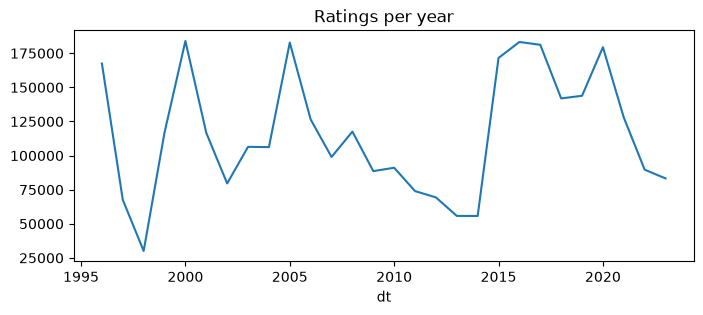

In [16]:
ratings["dt"] = pd.to_datetime(ratings["timestamp"], unit="s")
print(ratings.dt.min(), "→", ratings.dt.max())
ratings.groupby(ratings.dt.dt.year).size().plot(figsize=(8, 3), title="Ratings per year")
plt.show()

# Movie metadata: genres and release year

**Goal:** inspect the item-side information available for the content-based model.

**Why:** genres (a `|`-separated string) will become multi-hot features, and the year hidden in the title becomes a numeric feature. This section also shows where content features are weak, such as movies listed with no genres, which is where we'd lean on TMDB metadata.

**Look for:** genre balance, titles missing a year, and the number of movies with no genres.

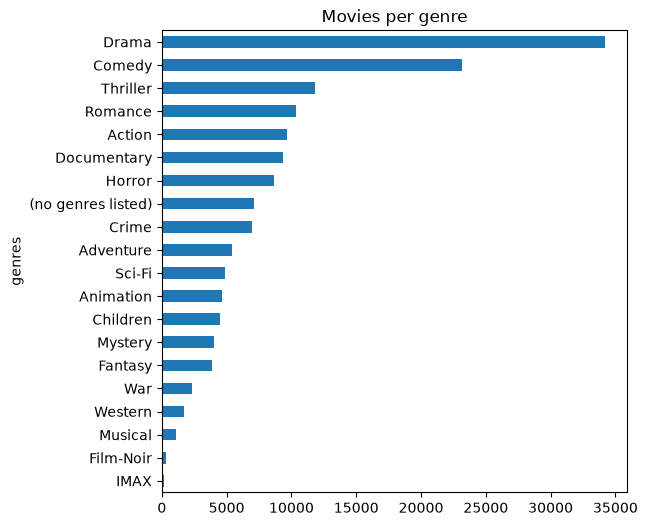

titles without a year: 617
movies with no genres: 7080


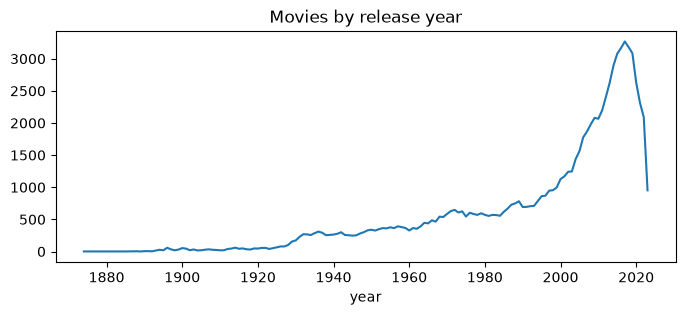

In [17]:
genre_counts = movies["genres"].str.split("|").explode().value_counts()
genre_counts.plot.barh(figsize=(6, 6), title="Movies per genre").invert_yaxis()
plt.show()

movies["year"] = movies["title"].str.extract(r"\((\d{4})\)\s*$").astype("float")
print("titles without a year:", movies["year"].isna().sum())
print("movies with no genres:", (movies.genres == "(no genres listed)").sum())
movies["year"].dropna().astype(int).value_counts().sort_index().plot(figsize=(8, 3), title="Movies by release year")
plt.show()

# User tags: a possible extra content signal

**Goal:** check how much free-text tag data exists and what it looks like.

**Why:** tags can capture ideas genres can't ("mind-bending", "dark comedy"), but they're sparse. Here we decide whether they're worth building features from or should be skipped.

In [18]:
print(tags.shape, "| users who tagged:", tags.userId.nunique(),
      "| movies tagged:", tags.movieId.nunique())
tags["tag"].str.lower().value_counts().head(20)

(94469, 4) | users who tagged: 1630 | movies tagged: 8484


tag
sci-fi                975
atmospheric           932
comedy                758
surreal               740
funny                 699
visually appealing    655
action                594
based on a book       572
dark comedy           549
thought-provoking     546
quirky                544
twist ending          519
dystopia              515
social commentary     462
stylized              444
dark                  439
cinematography        437
classic               425
coming of age         419
psychology            403
Name: count, dtype: int64

## Findings and decisions (sample_10pct)

| Question | What we found | Decision |
|---|---|---|
| Are ratings skewed? | Mean 3.54, mode 4.0; whole stars preferred | Evaluate with ranking metrics (NDCG@10, Recall@10); RMSE secondary |
| How heavy is the long tail? | Median movie has 3 ratings; top 10% of movies hold 88.5% of ratings; 63% of movies have ≤5 | Set a minimum-ratings threshold for CF training; handle low-count movies with content features; report a popularity baseline |
| How sparse is the matrix? | 99.62% empty | Matrix factorization / learned latent factors rather than raw neighbourhood methods |
| What time span? | 1996 to 2023, uneven activity | Per-user temporal split with deterministic tie-breaking |
| Are content features usable? | 8% of movies have no genres; tags cover ~10% of movies | Genres + year as base features; TMDB metadata to fill the gaps; tags as an optional extra |

**Next notebook:** `02_split_and_baselines`: build the temporal split and score a popularity baseline.

In [19]:
# 9 · Threshold impact: what do we keep at each minimum-ratings cut?
rows = []
for k in (1, 3, 5, 10, 20):
    keep_movies = per_movie[per_movie >= k].index
    kept = ratings[ratings.movieId.isin(keep_movies)]
    rows.append({
        "min_ratings_per_movie": k,
        "movies_kept": len(keep_movies),
        "movies_kept_%": round(100 * len(keep_movies) / len(per_movie), 1),
        "ratings_kept_%": round(100 * len(kept) / len(ratings), 2),
    })
pd.DataFrame(rows)

,min_ratings_per_movie,movies_kept,movies_kept_%,ratings_kept_%
0,1,42912,100.0,100.00
1,3,22184,51.7,99.18
2,5,17241,40.2,98.66
3,10,12817,29.9,97.77
4,20,9611,22.4,96.41


In [20]:
# 10 · Are no-genre movies also the rarely-rated ones?
no_genre = movies.loc[movies.genres == "(no genres listed)", "movieId"]
print("median ratings of no-genre movies:", per_movie.reindex(no_genre).fillna(0).median())
print("median ratings of all movies in ratings:", per_movie.median())

median ratings of no-genre movies: 0.0
median ratings of all movies in ratings: 3.0
